### OpenCV DNN + YOLO ONNX로 이미지 Object Detection
* OpenCV 5에서는 `readNetFromDarknet`이 제거되어 Darknet `.weights/.cfg` 대신 **ONNX** 모델을 사용한다.
* 예제에서는 Ultralytics YOLO26n(`yolo26n.onnx`)을 OpenCV DNN으로 추론한다.


image shape: (375, 500, 3)


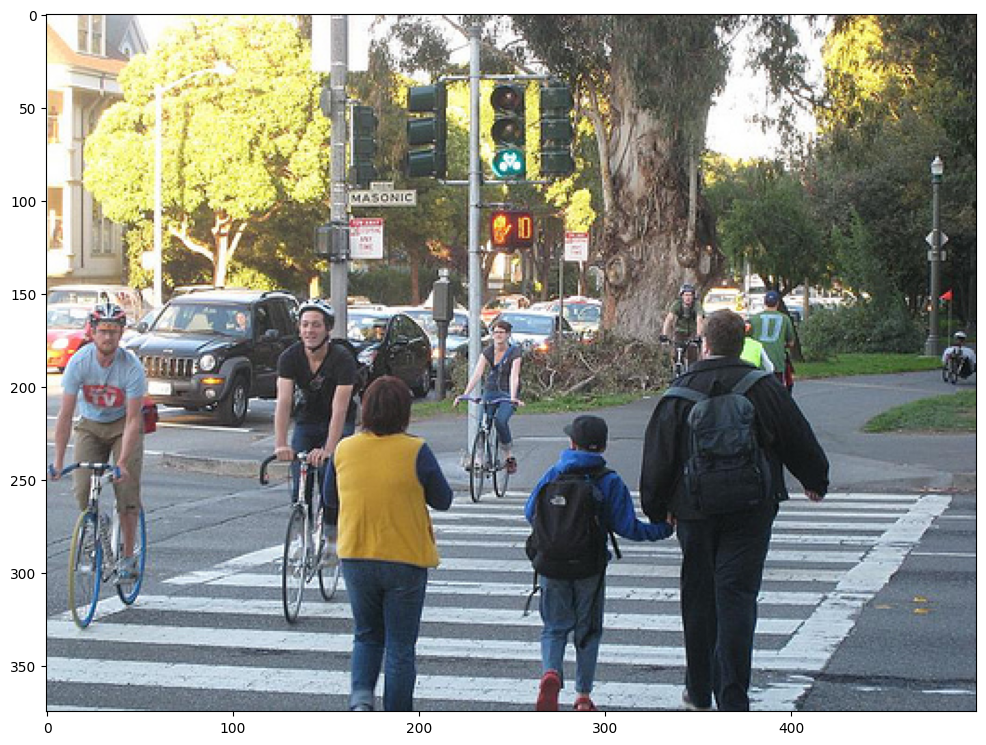

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('demo28.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print('image shape:', img.shape)
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)

#### COCO 학습 YOLO ONNX 모델을 OpenCV DNN으로 로딩

* OpenCV 5 DNN은 Darknet 로더가 없고 `readNetFromONNX` / `readNet`을 사용한다.
* 프로젝트 루트의 `yolo26n.onnx`를 사용한다. (없으면 Ultralytics로 export)
  ```python
  from ultralytics import YOLO
  YOLO('yolo26n.pt').export(format='onnx', imgsz=640)
  ```
* ONNX 경로만 있으면 되므로 별도 `.cfg`는 필요 없다.


#### `readNetFromONNX(onnx파일)`로 YOLO inference network 모델 로딩


In [2]:
# OpenCV 5: Darknet weights 대신 ONNX 사용
onnx_path = 'yolo26n.onnx'

# 만일 경로 오류 발생시 절대 경로를 사용한다
# onnx_path = r'C:/MyCursorLab/08_Object_Detection/yolo26n.onnx'

# readNetFromONNX 또는 readNet 모두 가능
cv_net_yolo = cv2.dnn.readNetFromONNX(onnx_path)
# cv_net_yolo = cv2.dnn.readNet(onnx_path)

INPUT_SIZE = (640, 640)  # YOLO26/Ultralytics ONNX 기본 입력 크기


#### COCO class id와 class 명 매핑

In [3]:
labels_to_names_seq = {0:'person',1:'bicycle',2:'car',3:'motorbike',4:'aeroplane',5:'bus',6:'train',7:'truck',8:'boat',9:'traffic light',10:'fire hydrant',
                        11:'stop sign',12:'parking meter',13:'bench',14:'bird',15:'cat',16:'dog',17:'horse',18:'sheep',19:'cow',20:'elephant',
                        21:'bear',22:'zebra',23:'giraffe',24:'backpack',25:'umbrella',26:'handbag',27:'tie',28:'suitcase',29:'frisbee',30:'skis',
                        31:'snowboard',32:'sports ball',33:'kite',34:'baseball bat',35:'baseball glove',36:'skateboard',37:'surfboard',38:'tennis racket',39:'bottle',40:'wine glass',
                        41:'cup',42:'fork',43:'knife',44:'spoon',45:'bowl',46:'banana',47:'apple',48:'sandwich',49:'orange',50:'broccoli',
                        51:'carrot',52:'hot dog',53:'pizza',54:'donut',55:'cake',56:'chair',57:'sofa',58:'pottedplant',59:'bed',60:'diningtable',
                        61:'toilet',62:'tvmonitor',63:'laptop',64:'mouse',65:'remote',66:'keyboard',67:'cell phone',68:'microwave',69:'oven',70:'toaster',
                        71:'sink',72:'refrigerator',73:'book',74:'clock',75:'vase',76:'scissors',77:'teddy bear',78:'hair drier',79:'toothbrush' }

#### ONNX Output layer 확인
* YOLO26 ONNX(end-to-end)는 보통 출력 1개이며 shape은 `(1, 300, 6)` 형태이다.
* 각 detection: `[x1, y1, x2, y2, confidence, class_id]` (입력 해상도 기준 좌표)


In [4]:
layer_names = cv_net_yolo.getLayerNames()
print('layer count:', len(layer_names))
print('unconnected out layers:', cv_net_yolo.getUnconnectedOutLayersNames())
# 예: ('output0',)


layer count: 253
unconnected out layers: ('output0',)


In [5]:
# ONNX 출력 레이어 이름 조회
outlayer_names = cv_net_yolo.getUnconnectedOutLayersNames()
print(outlayer_names)

img = cv2.imread('demo28.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Ultralytics YOLO ONNX 기본 입력은 640x640. BGR->RGB 변환 후 정규화
cv_net_yolo.setInput(cv2.dnn.blobFromImage(
    img, scalefactor=1/255., size=INPUT_SIZE, swapRB=True, crop=False
))

# Object Detection 수행
cv_outs = cv_net_yolo.forward(outlayer_names)
print(type(cv_outs), len(cv_outs))
print('output shape:', cv_outs[0].shape)  # 예: (1, 300, 6)
print(cv_outs[0][:1, :5])


('output0',)
<class 'tuple'> 1
output shape: (1, 300, 6)
[[[406.8964     269.46704    541.16956    639.0189       0.9338319
     0.        ]
  [193.94046    332.7041     282.05328    640.1371       0.8949265
     0.        ]
  [326.62045    366.67065    431.89844    639.81586      0.8593175
     0.        ]
  [281.0218     280.415      330.58167    419.34808      0.83154875
     0.        ]
  [480.81262    253.56425    519.5531     346.9887       0.77876973
     0.        ]]]


#### ONNX detection 결과 파싱
* 출력 `(1, N, 6)`에서 confidence threshold로 filtering 후, 640 입력 좌표를 원본 이미지 크기로 scale한다.
* YOLO26 end-to-end ONNX는 모델 내부에서 NMS가 적용된 결과가 나오는 경우가 많다.


In [6]:
import numpy as np

rows = img.shape[0]
cols = img.shape[1]

conf_threshold = 0.5
nms_threshold = 0.4  # end-to-end ONNX에서는 보통 추가 NMS 불필요(호환용 파라미터)

green_color = (0, 255, 0)
red_color = (0, 0, 255)

class_ids = []
confidences = []
boxes = []

# cv_outs[0]: (1, 300, 6) -> (300, 6)
detections = np.squeeze(cv_outs[0], axis=0)
print('detections shape:', detections.shape)

scale_x = cols / INPUT_SIZE[0]
scale_y = rows / INPUT_SIZE[1]

for detection in detections:
    x1, y1, x2, y2, confidence, class_id = detection
    if confidence > conf_threshold:
        left = int(x1 * scale_x)
        top = int(y1 * scale_y)
        width = int((x2 - x1) * scale_x)
        height = int((y2 - y1) * scale_y)
        class_ids.append(int(class_id))
        confidences.append(float(confidence))
        boxes.append([left, top, width, height])
        print('class_id', int(class_id), 'confidence:', float(confidence), 'box:', boxes[-1])

print('filtered boxes:', len(boxes))


detections shape: (300, 6)
class_id 0 confidence: 0.9338318705558777 box: [317, 157, 104, 216]
class_id 0 confidence: 0.8949264883995056 box: [151, 194, 68, 180]
class_id 0 confidence: 0.8593174815177917 box: [255, 214, 82, 160]
class_id 0 confidence: 0.8315487504005432 box: [219, 164, 38, 81]
class_id 0 confidence: 0.7787697315216064 box: [375, 148, 30, 54]
class_id 0 confidence: 0.7682538628578186 box: [1, 157, 59, 153]
class_id 1 confidence: 0.7532139420509338 box: [221, 206, 32, 56]
class_id 2 confidence: 0.691365659236908 box: [41, 148, 96, 74]
class_id 0 confidence: 0.6755865216255188 box: [329, 146, 24, 47]
class_id 24 confidence: 0.6716901659965515 box: [256, 243, 49, 60]
class_id 1 confidence: 0.6515893936157227 box: [9, 239, 43, 92]
class_id 9 confidence: 0.6443896889686584 box: [192, 37, 22, 51]
class_id 0 confidence: 0.5300767421722412 box: [113, 156, 55, 102]
filtered boxes: 13


- output shape 예: `(1, 300, 6)`
  - `6` = `x1, y1, x2, y2, confidence, class_id`
  - Darknet YOLOv3의 `(N, 85)` center/wh + class scores 형식과 다르다.


#### (선택) NMS로 중복 박스 정리
* end-to-end ONNX는 이미 NMS된 결과인 경우가 많아, 아래는 호환/실험용이다.
* 필요 시 `cv2.dnn.NMSBoxes`로 한 번 더 filtering 할 수 있다.


In [7]:
print(len(boxes))

conf_threshold = 0.5
nms_threshold = 0.4

# end-to-end 결과에도 추가 NMS를 적용해볼 수 있음
idxs = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)
if idxs is None or len(idxs) == 0:
    idxs = np.arange(len(boxes))
else:
    idxs = np.array(idxs).reshape(-1)

print(len(idxs))


13
13


#### filtering된 idxs로 boxes / classes / confidences를 시각화


person: 0.9338
person: 0.8949
person: 0.8593
person: 0.8315
person: 0.7788
person: 0.7683
bicycle: 0.7532
car: 0.6914
person: 0.6756
backpack: 0.6717
bicycle: 0.6516
traffic light: 0.6444
person: 0.5301


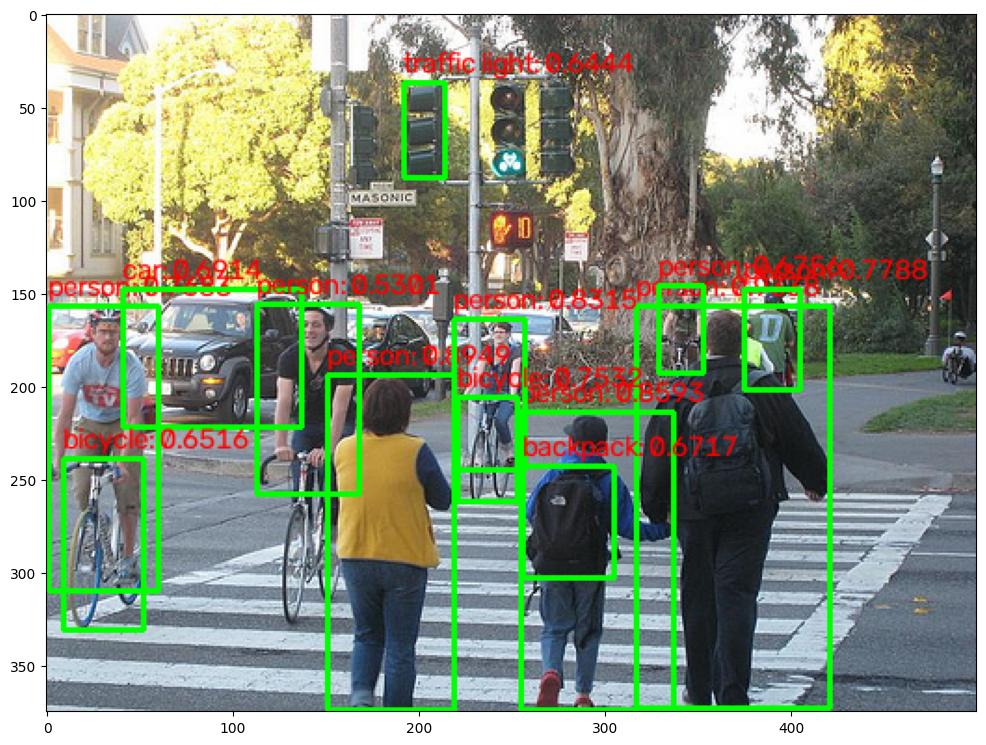

In [8]:
import matplotlib.pyplot as plt

# cv2.rectangle()은 입력 이미지를 in-place로 수정하므로 복사본 사용
draw_img = img.copy()

if len(idxs) > 0:
    for i in np.array(idxs).reshape(-1):
        box = boxes[i]
        left, top, width, height = box
        caption = "{}: {:.4f}".format(labels_to_names_seq[class_ids[i]], confidences[i])
        cv2.rectangle(draw_img, (int(left), int(top)), (int(left + width), int(top + height)), color=green_color, thickness=2)
        cv2.putText(draw_img, caption, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, red_color, 1)
        print(caption)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)


#### 임의의 이미지를 YOLO ONNX로 detect하는 `get_detected_img()` 함수 생성


In [9]:
def get_detected_img(cv_net, img_array, conf_threshold, nms_threshold, input_size=(640, 640), is_print=True):
    rows = img_array.shape[0]
    cols = img_array.shape[1]
    draw_img = img_array.copy()

    outlayer_names = cv_net.getUnconnectedOutLayersNames()
    cv_net.setInput(cv2.dnn.blobFromImage(
        img_array, scalefactor=1/255.0, size=input_size, swapRB=True, crop=False
    ))

    start = time.time()
    cv_outs = cv_net.forward(outlayer_names)

    green_color = (0, 255, 0)
    red_color = (0, 0, 255)

    class_ids = []
    confidences = []
    boxes = []

    detections = np.squeeze(cv_outs[0], axis=0)
    scale_x = cols / input_size[0]
    scale_y = rows / input_size[1]

    for detection in detections:
        x1, y1, x2, y2, confidence, class_id = detection
        if confidence > conf_threshold:
            left = int(x1 * scale_x)
            top = int(y1 * scale_y)
            width = int((x2 - x1) * scale_x)
            height = int((y2 - y1) * scale_y)
            class_ids.append(int(class_id))
            confidences.append(float(confidence))
            boxes.append([left, top, width, height])

    # end-to-end ONNX는 이미 NMS된 경우가 많지만, 호환을 위해 선택 적용
    idxs = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)
    if idxs is None or len(idxs) == 0:
        idxs = np.arange(len(boxes))
    else:
        idxs = np.array(idxs).reshape(-1)

    for i in idxs:
        left, top, width, height = boxes[i]
        caption = "{}: {:.4f}".format(labels_to_names_seq[class_ids[i]], confidences[i])
        cv2.rectangle(draw_img, (int(left), int(top)), (int(left + width), int(top + height)), color=green_color, thickness=2)
        cv2.putText(draw_img, caption, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, red_color, 1)

    if is_print:
        print('Detection 수행시간:', round(time.time() - start, 2), "초")
    return draw_img



In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import time

# image 로딩
img = cv2.imread('demo28.jpg')

onnx_path = 'yolo26n.onnx'
# onnx_path = r'C:/MyCursorLab/08_Object_Detection/yolo26n.onnx'

# YOLO ONNX pretrained 모델 로딩 (OpenCV 5)
cv_net_yolo = cv2.dnn.readNetFromONNX(onnx_path)
INPUT_SIZE = (640, 640)


Detection 수행시간: 0.06 초


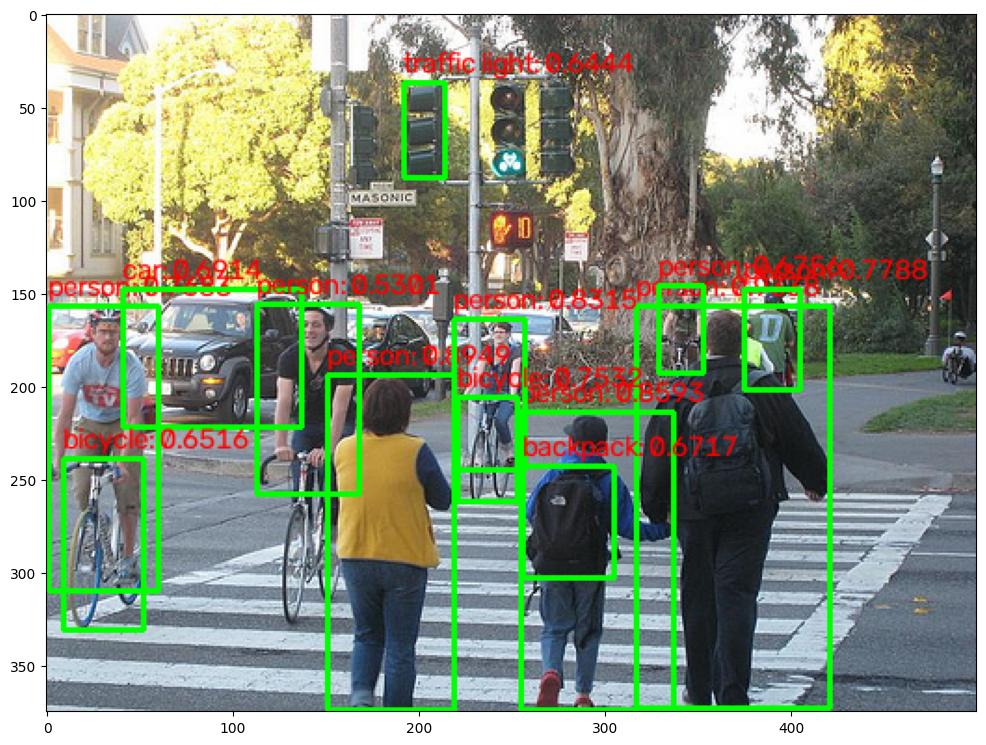

In [11]:
conf_threshold = 0.5
nms_threshold = 0.4
# Object Detetion 수행 후 시각화 
draw_img = get_detected_img(cv_net_yolo, img, conf_threshold=conf_threshold, nms_threshold=nms_threshold, is_print=True)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)

### 경량 YOLO(nano)로 Object Detection 수행하기
- 기존 tiny-yolo(Darknet) 대신, OpenCV 5 환경에서는 경량 ONNX 모델(예: YOLO26n)을 사용한다.
- 같은 `yolo26n.onnx`를 재사용하거나, 더 작은 모델을 export해 경로만 바꿔도 된다.
  ```python
  from ultralytics import YOLO
  YOLO('yolo26n.pt').export(format='onnx', imgsz=640)
  ```


In [12]:
img = cv2.imread('demo28.jpg')

# 경량 모델(ONNX). 별도 tiny onnx가 있으면 경로만 교체
onnx_path = 'yolo26n.onnx'
# onnx_path = r'C:/MyCursorLab/08_Object_Detection/yolo26n.onnx'

cv_net_yolo_tiny = cv2.dnn.readNetFromONNX(onnx_path)


Detection 수행시간: 0.07 초


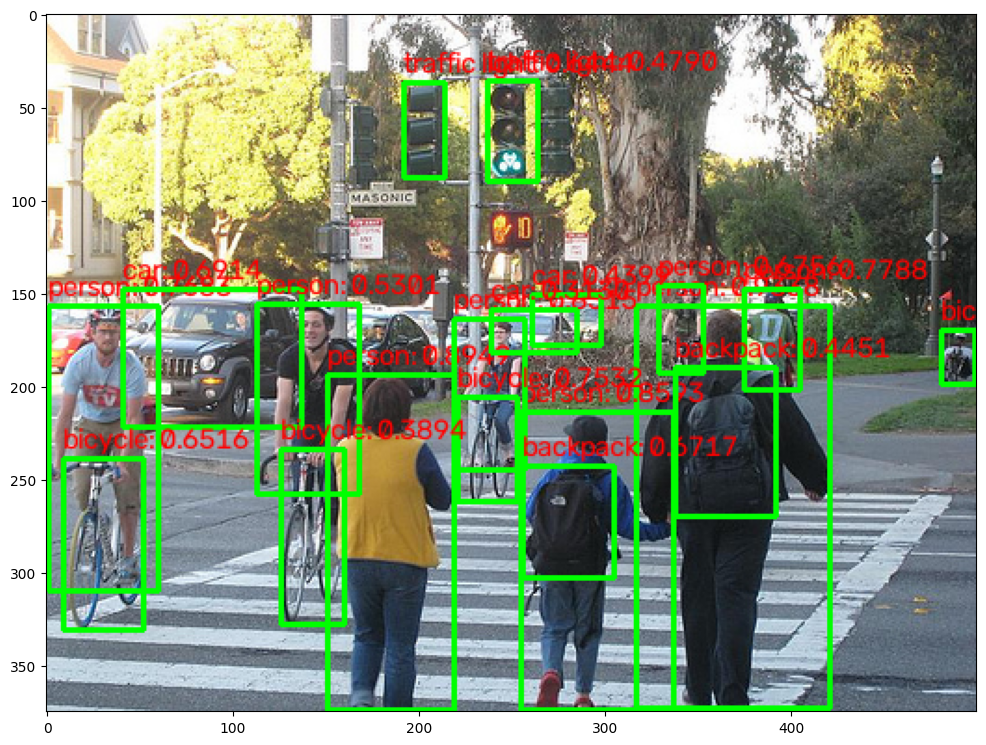

In [13]:
conf_threshold = 0.2
nms_threshold = 0.4
# Object Detetion 수행 후 시각화 
draw_img = get_detected_img(cv_net_yolo_tiny, img, conf_threshold=conf_threshold, nms_threshold=nms_threshold, is_print=True)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)